# Project 3 - Credit Risk Modeling (Notebook)

Pipeline simple et solide pour le sujet impose:
- Objective: predict borrower default probability
- Models: Logistic Regression, Random Forest, XGBoost, Neural Network (MLP)
- Evaluation: AUC, F1-score, Confusion Matrix


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight


In [3]:
# Optional deps checks (messages clairs)
try:
    from imblearn.over_sampling import SMOTE
except Exception as exc:
    raise RuntimeError('Installe imbalanced-learn: pip install -r requirements.txt') from exc

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise RuntimeError(
        'XGBoost indisponible. Sur Mac: brew install libomp puis relance.'
    ) from exc


In [4]:
# Configuration
OUTPUT_DIR = Path('outputs')
CM_DIR = OUTPUT_DIR / 'confusion_matrices'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# Chargement du fichier (Colab)
try:
    from google.colab import files
    uploaded = files.upload()

    if len(uploaded) == 0:
        raise ValueError('Aucun fichier televerse. Reessaie files.upload().')

    uploaded_filename = next(iter(uploaded.keys()))
    DATA_PATH = Path(uploaded_filename)
    print(f'Fichier charge via Colab: {DATA_PATH}')
except ImportError:
    # Fallback local (si notebook lance hors Colab)
    DATA_PATH = Path('data/default_of_credit_card_clients.xls')
    print(f'google.colab indisponible, fallback local: {DATA_PATH}')


Saving default_of_credit_card_clients.xls to default_of_credit_card_clients.xls
Fichier charge via Colab: default_of_credit_card_clients.xls


In [5]:
def normalize_column_name(name: str) -> str:
    return (
        str(name).strip().lower()
        .replace(' ', '_')
        .replace('.', '_')
        .replace('/', '_')
        .replace('-', '_')
    )

def load_credit_dataset(data_path: Path) -> pd.DataFrame:
    if not data_path.exists():
        raise FileNotFoundError(f'Dataset introuvable: {data_path}')

    if data_path.suffix.lower() == '.csv':
        df = pd.read_csv(data_path)
    elif data_path.suffix.lower() in {'.xls', '.xlsx'}:
        try:
            df = pd.read_excel(data_path)
            if 'default.payment.next.month' not in [str(c) for c in df.columns]:
                df = pd.read_excel(data_path, header=1)
        except Exception:
            df = pd.read_excel(data_path, header=1)
    else:
        raise ValueError('Format non supporte: utilise .csv/.xls/.xlsx')

    df = df.loc[:, ~df.columns.astype(str).str.contains('^Unnamed')]
    df.columns = [normalize_column_name(c) for c in df.columns]
    return df

def detect_target_column(columns: list[str]) -> str:
    candidates = [
        'default_payment_next_month',
        'default',
        'y',
        'target',
    ]
    for c in candidates:
        if c in columns:
            return c
    raise ValueError('Target introuvable: attendu default.payment.next.month')


In [6]:
# 1) Load dataset
df = load_credit_dataset(DATA_PATH)
target_col = detect_target_column(list(df.columns))

# Drop ID if present
id_cols = [c for c in df.columns if c in {'id', 'id_'} or c.startswith('id_')]
if id_cols:
    df = df.drop(columns=id_cols)

print('Shape:', df.shape)
print('Target:', target_col)
display(df.head())
display(df[target_col].value_counts(dropna=False))
display(df[target_col].value_counts(normalize=True).rename('ratio'))


Shape: (30000, 24)
Target: default_payment_next_month


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


,count
default_payment_next_month,
0,23364
1,6636


,ratio
default_payment_next_month,
0,0.7788
1,0.2212


## 2) Exploration rapide des donnees


In [ ]:
# EDA rapide: qualite des donnees
print('Types de variables:')
display(df.dtypes.value_counts().rename('count').to_frame())

print('Doublons:', int(df.duplicated().sum()))

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Missing values:')
if len(missing) == 0:
    print('Aucune valeur manquante detectee.')
else:
    display(missing.to_frame('missing_count'))

print('Statistiques descriptives (numeriques):')
display(df.describe(include=[np.number]).T.head(20))


In [ ]:
# Visualisation de la cible
counts = df[target_col].value_counts().sort_index()
ratios = df[target_col].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(counts.index.astype(str), counts.values)
axes[0].set_title('Target count (0=non-default, 1=default)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=[str(i) for i in counts.index], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target ratio')

plt.tight_layout()
plt.show()

print('Table distribution cible:')
display(pd.DataFrame({'count': counts, 'ratio': ratios}))


In [7]:
# 3) Train/Test split (stratified)
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print('Train class distribution:')
display(y_train.value_counts())
display(y_train.value_counts(normalize=True).rename('ratio'))
print(f'scale_pos_weight = {scale_pos_weight:.2f}')
print('class_weight_dict =', class_weight_dict)


Train shape: (24000, 23)
Test shape : (6000, 23)
Train class distribution:


,count
default_payment_next_month,
0,18691
1,5309


,ratio
default_payment_next_month,
0,0.778792
1,0.221208


scale_pos_weight = 3.52


In [8]:
# 4) Handle imbalance for MLP with SMOTE (train only)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('After SMOTE (for MLP):')
display(pd.Series(y_train_smote).value_counts())


After SMOTE (for MLP):


,count
default_payment_next_month,
0,18691
1,18691


In [9]:
# 5) Define required models
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight=class_weight_dict,
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ),

    'Neural Network (MLP)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])
}

print('Imbalance strategies:')
print('- Logistic/Random Forest -> class_weight_dict')
print('- XGBoost -> scale_pos_weight')
print('- MLP -> SMOTE on train set')


## 6) Lasso + Random Forest (importance des variables)


In [ ]:
# Lasso (L1 Logistic) pour variables importantes
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=0.1,
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        max_iter=2000
    ))
])
lasso_pipe.fit(X_train, y_train)

lasso_coef = pd.Series(
    lasso_pipe.named_steps['model'].coef_[0],
    index=X_train.columns
)

print('Top features by |L1 coefficient|:')
display(lasso_coef.abs().sort_values(ascending=False).head(10).to_frame('abs_l1_coef'))

# Random Forest importances (rapide)
rf_selector = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_selector.fit(X_train, y_train)

rf_importance = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
print('Top features by RF importance:')
display(rf_importance.sort_values(ascending=False).head(10).to_frame('rf_importance'))

feature_screen = pd.DataFrame({
    'feature': X_train.columns,
    'lasso_abs_coef': lasso_coef.abs().values,
    'rf_importance': rf_importance.values
}).sort_values(['rf_importance', 'lasso_abs_coef'], ascending=False)

feature_screen.to_csv(OUTPUT_DIR / 'feature_screen_lasso_rf.csv', index=False)
print('Saved:', OUTPUT_DIR / 'feature_screen_lasso_rf.csv')


In [10]:
# 5) Cross-validation (3-fold stratified on train set)
from imblearn.pipeline import Pipeline as ImbPipeline

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': clone(models['Logistic Regression']),
    'Random Forest': clone(models['Random Forest']),
    'XGBoost': clone(models['XGBoost']),
    'Neural Network (MLP)': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])
}

cv_rows = []
for model_name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={'auc': 'roc_auc', 'f1': 'f1'},
        n_jobs=-1,
        error_score='raise'
    )

    cv_rows.append({
        'model': model_name,
        'cv_auc_mean': round(float(np.mean(scores['test_auc'])), 4),
        'cv_auc_std': round(float(np.std(scores['test_auc'])), 4),
        'cv_f1_mean': round(float(np.mean(scores['test_f1'])), 4),
        'cv_f1_std': round(float(np.std(scores['test_f1'])), 4),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('cv_auc_mean', ascending=False)
display(cv_df)
cv_df.to_csv(OUTPUT_DIR / 'cv_results.csv', index=False)
print('CV results saved to:', OUTPUT_DIR / 'cv_results.csv')


,model,cv_auc_mean,cv_auc_std,cv_f1_mean,cv_f1_std
2,XGBoost,0.7824,0.0075,0.5391,0.0092
1,Random Forest,0.7810,0.0037,0.5419,0.0052
3,Neural Network (MLP),0.7360,0.0060,0.4863,0.0023
0,Logistic Regression,0.7263,0.0114,0.4801,0.0117


CV results saved to: outputs/cv_results.csv


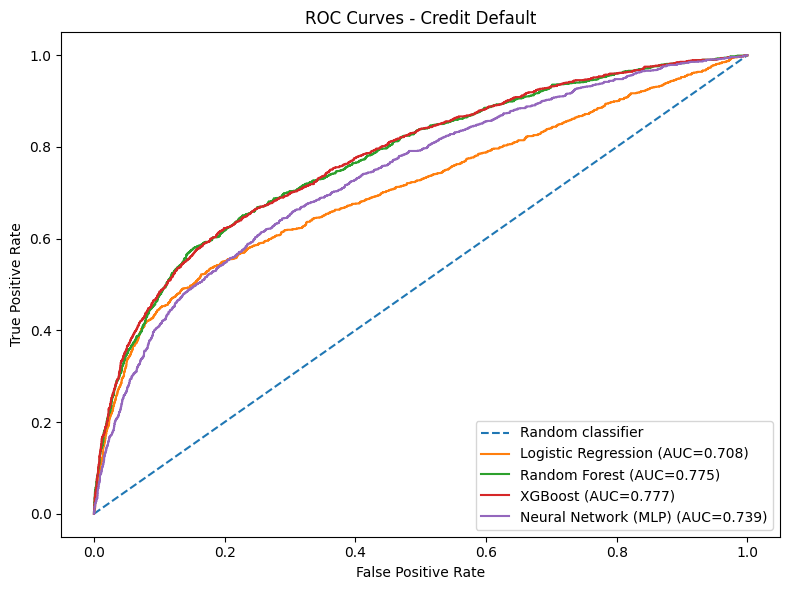

,model,auc,f1_score,tn,fp,fn,tp
2,XGBoost,0.7770,0.5350,3752,921,506,821
1,Random Forest,0.7750,0.5469,3954,719,557,770
3,Neural Network (MLP),0.7388,0.4863,3743,930,602,725
0,Logistic Regression,0.7081,0.4613,3255,1418,504,823


Resultats sauvegardes dans: /content/outputs


,model,cv_auc_mean,cv_auc_std,cv_f1_mean,cv_f1_std,auc,f1_score,tn,fp,fn,tp
0,XGBoost,0.7824,0.0075,0.5391,0.0092,0.7770,0.5350,3752,921,506,821
1,Random Forest,0.7810,0.0037,0.5419,0.0052,0.7750,0.5469,3954,719,557,770
2,Neural Network (MLP),0.7360,0.0060,0.4863,0.0023,0.7388,0.4863,3743,930,602,725
3,Logistic Regression,0.7263,0.0114,0.4801,0.0117,0.7081,0.4613,3255,1418,504,823


Resultats sauvegardes dans: /content/outputs


In [11]:
# 6) Final training on full train set + test evaluation
results = []

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')

for model_name, model in models.items():
    if model_name == 'Neural Network (MLP)':
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'model': model_name,
        'auc': round(float(auc), 4),
        'f1_score': round(float(f1), 4),
        'tn': int(cm[0, 0]),
        'fp': int(cm[0, 1]),
        'fn': int(cm[1, 0]),
        'tp': int(cm[1, 1]),
    })

    # Save confusion matrix figure
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig.savefig(CM_DIR / f'cm_{safe_name}.png')
    plt.close(fig)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Credit Default')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png')
plt.show()

results_df = pd.DataFrame(results).sort_values('auc', ascending=False)
results_df.to_csv(OUTPUT_DIR / 'model_results.csv', index=False)

display(results_df)
print(f'Resultats sauvegardes dans: {OUTPUT_DIR.resolve()}')

results_df = pd.DataFrame(results).sort_values('auc', ascending=False)
if 'cv_df' in globals():
    final_df = results_df.merge(cv_df, on='model', how='left')
else:
    final_df = results_df.copy()
# ordre de colonnes plus lisible pour presentation
preferred_cols = [
    'model', 'cv_auc_mean', 'cv_auc_std', 'cv_f1_mean', 'cv_f1_std',
    'auc', 'f1_score', 'tn', 'fp', 'fn', 'tp'
]
final_cols = [c for c in preferred_cols if c in final_df.columns]
final_df = final_df[final_cols]
final_df.to_csv(OUTPUT_DIR / 'model_results.csv', index=False)
display(final_df)
print(f'Resultats sauvegardes dans: {OUTPUT_DIR.resolve()}')


## 10) Notes de travail
- Les points demandes ont ete integres dans les sections 2, 3, 5 et 6.


## A mettre dans la presentation
- Tableau final `model_results.csv` (CV + test: AUC/F1 + TN/FP/FN/TP)
- Tableau `cv_results.csv` (stabilite des modeles en 3-fold CV)
- Figure `roc_curves.png`
- 4 images de matrice de confusion dans `outputs/confusion_matrices/`
